# Photonic Hopfield
### This scripts provide some useful function to characterize a given scattering matrix S in the framework of a interferometric experiment as it has been described in [Multiphoton Quantum Simulation of the Generalized Hopfield Memory Model](https://https://journals.aps.org/prl/pdf/10.1103/945c-11wt). Example of usage are provided in the script.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Standard function for generating matrix and building permanents, the *gauge_unfixing* function is needed to unbias the result of *numpy* bultin function *np.linalg.eig*.

In [4]:
def generate_random_haar(n: int, rng = np.random.default_rng()):

    """
    This function generates an nxn random Haar
    matrix according to the article by Mezzadri. (QR decomposition)
    """

    Z = (rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))) / np.sqrt(2.0) # random initializing
    Q, R = np.linalg.qr(Z) # QR decomposition step
    d = np.diag(R)
    ph = d / np.abs(d)
    Q = Q * np.conj(ph)

    return Q

def gauge_unfixing(vector):
  """
  In general when you perform a linalg algorithm function there's some bias on the eigvec phase,
  this should manage the issue by defining a random phase for each vector

  """
  ɸ = np.random.uniform(0, 2*np.pi)
  return vector * np.exp(1j * ɸ)


def build_perm(Sk1, Sk2):
  """Build permanent form"""
  return np.outer(Sk1, Sk2) + np.outer(Sk1, Sk2)

## This function aligns the sign of the real and imaginary part of the eigenvector with the maximum eigenvalue

In [5]:
def align_sigma_vector(eigvals, eigvecs):
    """
    This function aligns an array of +-1 value (our phases) to the sign of
    the real (and imaginary) part of the maximum eigenvalue eigenvector.

    Args:
        eigvals (np.ndarray): eigenvalues array.
        eigvecs (np.ndarray): eigenvectors array.

    Returns:
        np.ndarray: aligned phases vector (+1 o -1) for real alignment.
        np.ndarray: aligned phases vector (+1 o -1) for imaginary alignment
        np.ndarray: selected maximum eigvec
        complex: max eigval.
    """
    # find the index relative to the maximal eigvalue in modulus
    selected_idx = np.argmax(np.sqrt(eigvals.real**2+eigvals.imag**2))

    selected_eigenvalue = eigvals[selected_idx]
    selected_eigenvector = eigvecs[:, selected_idx]
    selected_eigenvector = gauge_unfixing(eigvecs[:, selected_idx]) # phase freedom randomized

    # extract the alignment part
    target_part = selected_eigenvector.real

    # create the sigma vector (phases)
    sigma_r = np.where(target_part >= 0, 1, -1)

    target_part = selected_eigenvector.imag

    # create the sigma vector (phases)
    sigma_i = np.where(target_part >= 0, 1, -1)

    return sigma_r, sigma_i, selected_eigenvector, selected_eigenvalue


The overlap is defined as:
$$\mathbb M^{(k_1,k_2)} = \left(1-\delta_{k_1,k_2}\right) \left[\sqrt{2}\,  m_{k_1} m_{k_2}
    + \frac{2-\sqrt{2}}{ M}  S^{(k_1)T}\cdot  S^{(k_2)}
     \right]+ \delta_{k_1,k_2}\left[
\left(m^{(k_1)}\right)^2+
\frac{\sqrt{2}-1}{ M}  S^{(k_1)T}\cdot  S^{(k_1)}
\right]$$
where $$m^{(k)} \equiv \frac{1}{\sqrt{M}}\sum_{x=1}^M S_{k,x}\, \sigma_x \quad ; \quad \max_{M\gg 1} m^{(k)}=O(1)$$

In [6]:
def run_experiment(S, k1, k2):
    """
    This function is an experiment run:
    fixing a scattering matrix and the two measuring modes k1 and k2
    you get the max eigvec and eigval, the best sigmas i.e. the one
    aligned respectively to the real and the imaginary part, and the
    corresponding overlap considering the two configurations
    """
    Sk1 = S[k1,:]
    Sk2 = S[k2,:]
    M = np.size(Sk1) # mode number
    𝕏 = build_perm(Sk1, Sk2)
    eigvals_perm, eigvecs_perm = np.linalg.eig(𝕏) # linearizes the matrix

    threshold = 1e-14
    rounded_eigvals_perm = np.copy(eigvals_perm)

    # Set tiny imaginary parts to zero
    rounded_eigvals_perm.imag[np.abs(rounded_eigvals_perm.imag) < threshold] = 0.0

    # Set tiny real parts to zero
    rounded_eigvals_perm.real[np.abs(rounded_eigvals_perm.real) < threshold] = 0.0

    # compute best sigmas choosing both real and imaginary alignment

    sigma_real, sigma_imaginary, selected_eigenvector, selected_eigenvalue = align_sigma_vector(eigvals_perm, eigvecs_perm)

    if (k1 != k2):

        𝕄_real = (np.sqrt(2)/M)*np.dot(Sk1, sigma_real)*np.dot(Sk2, sigma_real) + ((2-np.sqrt(2))/M) * np.dot(Sk2, Sk1)

        𝕄_imaginary = (np.sqrt(2)/M)*np.dot(Sk1, sigma_imaginary)*np.dot(Sk2, sigma_imaginary) + ((2-np.sqrt(2))/M) * np.dot(Sk2, Sk1)

        #𝕄_real = (2*np.sqrt(2)/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_real)*np.dot(Sk2, sigma_real)

        #𝕄_imaginary = (2*np.sqrt(2)/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_imaginary)*np.dot(Sk2, sigma_imaginary)

    else: # bunched configuration

        𝕄_real = (1/M)*np.dot(Sk1, sigma_real)**2 - ((np.sqrt(2)-1)/M) * np.dot(Sk2, Sk1)

        𝕄_imaginary = (1/M)*np.dot(Sk1, sigma_imaginary)**2 - ((np.sqrt(2)-1)/M) * np.dot(Sk2, Sk1)

        #𝕄_real = (2/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_real)**2 - (2 - np.sqrt(2))/np.sqrt(M*(M+1))

        #𝕄_imaginary = (2/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_imaginary)**2 - (2 - np.sqrt(2))/np.sqrt(M*(M+1))


    return sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvector, selected_eigenvalue






## Note
### 𝕄_real and 𝕄_imaginary are not the real and imaginary part of 𝕄, but on the contrary the complex value of 𝕄 with the two different alignment framework

In [7]:
# use example

n = 10

S = generate_random_haar(n)

k1 = 0
k2 = 1
sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvector, selected_eigenvalue = run_experiment(S, k1, k2)
print(S)

[[ 0.02448395-0.00275877j -0.2018499 -0.30218269j -0.45278057-0.19913479j
   0.03450334-0.17003036j  0.10030696+0.22980482j  0.21226339+0.1205428j
   0.15863503-0.39735523j -0.12307539+0.16935691j -0.09839594-0.10913048j
  -0.45505821+0.12065087j]
 [-0.17267485-0.29412752j  0.24973081+0.06274863j  0.03771147-0.27703389j
  -0.31458564-0.2587317j  -0.00588262+0.34461365j -0.06966821+0.07384848j
   0.03749809+0.06288718j  0.17557557-0.25024588j  0.07207495+0.42226306j
  -0.03670076+0.40066747j]
 [-0.46536939-0.00778516j -0.20756285+0.28575986j  0.08392362-0.21632379j
   0.04737451+0.44390614j  0.0167643 +0.28416487j  0.06950431-0.10903366j
   0.11739648-0.18125435j  0.4459321 +0.12098499j -0.12799237-0.08812735j
   0.00881934-0.15293622j]
 [ 0.19216048-0.15111071j  0.16260317+0.0566631j  -0.0335685 +0.05583064j
  -0.26794329-0.26911651j  0.31021866-0.04638998j  0.5295476 -0.14094492j
   0.17393446+0.01622287j  0.28117916-0.21384078j -0.12619496-0.15512422j
   0.09488752-0.39894373j]
 [-0.

In [8]:
print(sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvalue)
print("")
print(selected_eigenvector)

[ 1 -1 -1 -1  1  1  1 -1 -1 -1] [-1 -1 -1 -1  1  1 -1  1 -1  1] (-0.11764544034190103-0.006639549834077591j) (-0.22544219585479663+0.06777474617001285j) (-0.4159787242681332-0.14486819880246377j)

[ 0.02331091-0.00797972j -0.26232987-0.25147724j -0.48509488-0.09668441j
 -0.00301944-0.17346956j  0.14755553+0.20272915j  0.23328224+0.07187288j
  0.06910596-0.4222329j  -0.08360913+0.19193443j -0.11963634-0.08531336j
 -0.418278  +0.2160512j ]


In [9]:
def check_unitary(S):
    """
    Return a Bool True/False if the matrix is unitary or not

    """
    out = True # initial assumption
    tol = 10**(-14) # error tolerance
    for i in range(len(S)):
        count = 0
        for j in range(len(S)):
            count += np.dot(np.conjugate(S[i,j]), S[i,j])
        if count > 1+tol or count < 1-tol:
            out = False
    return out


In [10]:
# hand construction of a matrix which is not unitary
S = np.zeros((n, n), dtype=complex)
# print(S.shape)

# filling the matrix wrongfully

for i in range(n):
    for r in range(n):
        S[i, r] = np.random.randn() + 1j*np.random.randn()# this is not unitary but a complex number

check_unitary(S)

False

In [11]:
n = 10
S = generate_random_haar(n)
check_unitary(S)

True

## Now the idea is to run an experiment measuring all possible combinations of pairs detectors. You can decide if you want to exclude bunched configurations by the bool *exclude_bunched* var False or True valued. The *run_all_alignment* function will give all the variables connected to all this configurations. Then *find_best_alignment* will give you the best k pair (the one that maximizes the modulus of $\mathbb{M}$) and the setting for the sigma, and the corresponding eigvec and eigval.

In [12]:
"""
def run_all_alignment(S, exclude_bunched):
    """
    # Iterates through k1, k2 pairs to run experiments and collect results.
    # Input: S: the matrix, exclude_bunched: bool variable that when set True exclude all bunched conf
    # this is because those are always the maximal ones wrt the not bunched.
    """
    if not check_unitary(S):
        raise ValueError("Input matrix is not unitary!")
    if not isinstance(exclude_bunched, bool):
        raise ValueError("exclude_bunched must be a boolean!")
    # Initialize storage
    results = {
        "sigma_r": [], "sigma_i": [],
        "M_r": [], "M_i": [],
        "e_vec": [], "e_val": [],
        "k_pairs": []
    }

    n = len(S)
    # print(f"Running experiments for number of modes: {n}")

    # Tracking variables for the maximum modulus
    max_modulus = -1.0
    best_k = (0, 0)
    norm_r = 0
    norm_i = 0

    for k1 in range(n):
        for k2 in range(n):
          if exclude_bunched:
            if (k1!=k2):
              # Run the experiment
              s_r, s_i, m_r, m_i, e_vec, e_val = run_experiment(S, k1, k2)
              results["sigma_r"].append(s_r)
              results["sigma_i"].append(s_i)
              results["M_r"].append(m_r)
              results["M_i"].append(m_i)
              results["e_vec"].append(e_vec)
              results["e_val"].append(e_val)
              results["k_pairs"].append((k1, k2))
              norm_r += abs(m_r)**2
              norm_i += abs(m_i)**2

              # Logic to find the maximum modulus of M_real or M_imaginary
              # Modulus in this context is just the absolute value: |x|
              current_max = max(abs(m_r)**2, abs(m_i)**2)

              if current_max > max_modulus:
                  max_modulus = current_max
                  best_k = (k1, k2)


                  if (abs(m_r)**2 > abs(m_i)**2):
                    choose_norm = 0
                  else:
                    choose_norm = 1
          else:
            # Run the experiment
            s_r, s_i, m_r, m_i, e_vec, e_val = run_experiment(S, k1, k2)
            results["sigma_r"].append(s_r)
            results["sigma_i"].append(s_i)
            results["M_r"].append(m_r)
            results["M_i"].append(m_i)
            results["e_vec"].append(e_vec)
            results["e_val"].append(e_val)
            results["k_pairs"].append((k1, k2))
            norm_r += abs(m_r)**2
            norm_i += abs(m_i)**2

            # Logic to find the maximum modulus of M_real or M_imaginary
            # Modulus in this context is just the absolute value: |x|
            current_max = max(abs(m_r)**2, abs(m_i)**2)

            if current_max > max_modulus:
                  max_modulus = current_max
                  best_k = (k1, k2)


                  if (abs(m_r)**2 > abs(m_i)**2):
                    choose_norm = 0
                  else:
                    choose_norm = 1

    if choose_norm == 0:
      max_modulus = abs(max_modulus)**2/norm_r
    else:
      max_modulus = abs(max_modulus)**2/norm_i

    results["M_r"] = results["M_r"]/np.sqrt(norm_r)
    results["M_i"] = results["M_i"]/np.sqrt(norm_i)
    print(f"--- Experiment Complete ---")
    print(f"Best couple (k1, k2): {best_k} with Max Modulus: {max_modulus}")

    return results, best_k
"""

IndentationError: unexpected indent (3925518119.py, line 7)

In [30]:
def run_all_alignment(S, exclude_bunched, norm, do_a_print):
    # exclude_bunched and norm are bool var to exclude bunched
    # config and to put or not to put a norm factor
    if not check_unitary(S):
        raise ValueError("Input matrix is not unitary!")

    # Initialize the storage
    results = {
        "sigma_r": [], "sigma_i": [],
        "M_r": [], "M_i": [],
        "e_vec": [], "e_val": [],
        "k_pairs": []
    }

    n = len(S)
    max_val_sq = -1.0
    best_k = (0, 0)
    norm_r = 0.0
    norm_i = 0.0
    choose_norm = 0 # Default safe value

    for k1 in range(n):
        for k2 in range(n):
            # if exclude_bunched is true and we are on diagonal jump
            if exclude_bunched and (k1 == k2):
                continue
            if k1> k2:
               continue # sum only lower diag
            # run experiment
            s_r, s_i, m_r, m_i, e_vec, e_val = run_experiment(S, k1, k2)

            # norm computation
            m_r_sq = abs(m_r)**2
            m_i_sq = abs(m_i)**2
            norm_r += m_r_sq
            norm_i += m_i_sq

            # save data
            results["sigma_r"].append(s_r)
            results["sigma_i"].append(s_i)
            results["M_r"].append(m_r_sq)
            results["M_i"].append(m_i_sq)
            results["e_vec"].append(e_vec)
            results["e_val"].append(e_val)
            results["k_pairs"].append((k1, k2))

            # find the max
            current_max_sq = max(m_r_sq, m_i_sq)

            if current_max_sq > max_val_sq:
                max_val_sq = current_max_sq
                best_k = (k1, k2)
                # choose the right norm
                choose_norm = 0 if m_r_sq > m_i_sq else 1

    # final norm
    if norm == True:
      divisor = norm_r if choose_norm == 0 else norm_i
      # 2. numpy conv
      results["M_r"] = np.array(results["M_r"]) / np.sqrt(norm_r) if norm_r > 0 else np.array(results["M_r"])
      results["M_i"] = np.array(results["M_i"]) / np.sqrt(norm_i) if norm_i > 0 else np.array(results["M_i"])
    elif norm == False:
      divisor = 1
    else:
      raise ValueError("norm must be a boolean!")
    final_max_modulus = max_val_sq / divisor if divisor != 0 else 0
    if do_a_print:
      print(f"--- Experiment Complete ---")
      print(f"Best couple (k1, k2): {best_k} with Max Modulus : {final_max_modulus:.6f}")
      print(f"Norm r: {norm_r}, Norm i: {norm_i}")

    return results, best_k, norm_r, norm_i

In [31]:
n = 10
S = generate_random_haar(n)

results, best_k, norm_r, norm_i = run_all_alignment(S,False, False, True)

--- Experiment Complete ---
Best couple (k1, k2): (0, 0) with Max Modulus : 0.277733
Norm r: 2.8335566714382145, Norm i: 4.614773979180305


0.22098727965011788


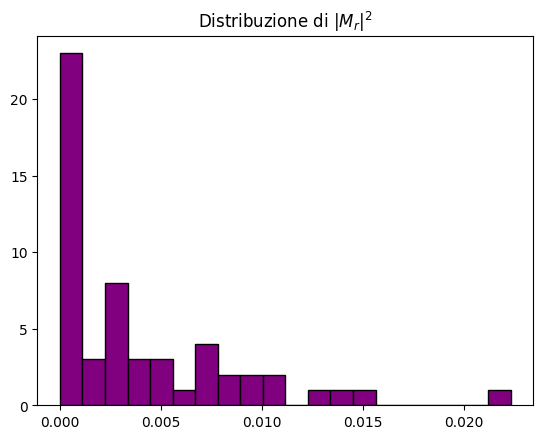

In [32]:
# Calcolo del modulo quadro totale
M_total_squared = abs(np.array(results["M_r"]))**2
print(np.sum(M_total_squared))

plt.hist(M_total_squared, bins=20, color='purple', edgecolor='black')
plt.title(r'Distribuzione di $|M_{r}|^2$')
plt.show()

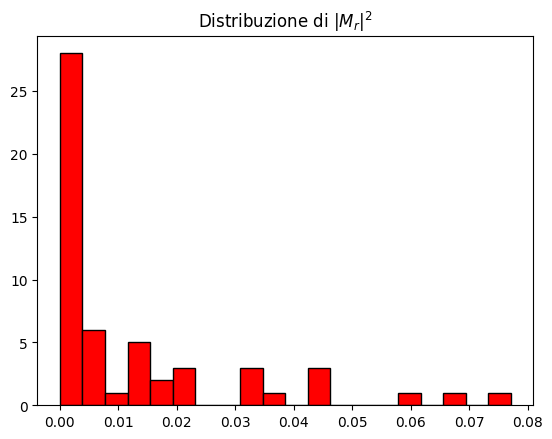

In [33]:
# Calcolo del modulo quadro totale
M_total_squared = abs(np.array(results["M_i"]))**2

plt.hist(M_total_squared, bins=20, color='red', edgecolor='black')
plt.title(r'Distribuzione di $|M_{r}|^2$')
plt.show()

In [34]:
def find_best_alignment(S, exclude_bunched, norm, do_a_print):

  """
  Given the results of all perms run of function run_alignment this
  function output the sigma_r sigma_i, M_r, M_i, e_vec, e_val maximal
  given a certain matrix S and the exclude_bunched setting
  """
  results, best_k, norm_r, norm_i = run_all_alignment(S, exclude_bunched, norm, do_a_print)
  idx = results["k_pairs"].index(best_k)

  sigma_r = results["sigma_r"][idx]
  sigma_i = results["sigma_i"][idx]
  M_r = results["M_r"][idx]
  M_i = results["M_i"][idx]
  e_vec = results["e_vec"][idx]
  e_val = results["e_val"][idx]
  return sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k

In [36]:
n = 30
S = generate_random_haar(n)

best_sigma_r, best_sigma_i, best_M_r, best_M_i, best_e_vec, best_e_val, best_k = find_best_alignment(S, exclude_bunched=False, norm = False, do_a_print = True)

--- Experiment Complete ---
Best couple (k1, k2): (29, 29) with Max Modulus : 0.262485
Norm r: 10.84095854782021, Norm i: 10.877832783314043


In [37]:

Sk1 = S[best_k[0],:]
Sk2 = S[best_k[1],:]
m_k = np.dot(Sk1, best_sigma_r) / np.sqrt(n) # Normalizzazione standard
𝕄_real = np.abs(m_k)**4 # Questo dovrebbe essere O(1)

print(𝕄_real)

0.043852170669471745


In [38]:
print(S, best_sigma_r, best_sigma_i, abs(best_M_i)**2, abs(best_M_r)**2)

[[ 8.85729291e-02+8.67765098e-02j -1.55216102e-01+5.42143538e-02j
  -9.41693659e-02-1.04976935e-01j -5.47702679e-02-1.16469354e-01j
   1.27929605e-01+1.59591649e-01j -4.76537346e-02-2.14607618e-01j
  -1.20301630e-01-2.73173822e-01j -3.91964080e-02-6.58716819e-02j
   3.77573177e-02-1.39928191e-02j  5.14493628e-02+3.29741239e-02j
   1.24021774e-01-1.02248440e-01j  2.09622200e-01+7.47006420e-02j
  -1.63526643e-01+7.06486881e-03j -3.94748515e-04+8.88516859e-02j
   2.29214214e-02-9.26558212e-02j  2.27353201e-01+2.23788490e-01j
  -4.54505968e-02+4.40402827e-02j -1.48490403e-01-1.23257216e-03j
   1.42795379e-01-1.10391974e-03j -1.98866787e-01+1.50171000e-01j
   5.43573480e-02+4.67891056e-02j  8.76090885e-02-8.17887370e-02j
  -3.87475728e-01-6.86705663e-02j  3.87534983e-03-7.89823358e-02j
   5.39434126e-03-2.51537391e-01j -5.66641592e-02-2.40715105e-01j
   1.13365945e-02+1.20994755e-01j -9.31956552e-02+1.41608961e-01j
   4.13960416e-02+3.02821931e-02j  1.49711102e-01-1.66004665e-01j]
 [ 8.1481

In [39]:
print( (7-4*np.sqrt(2)-2*(2-np.sqrt(2))*np.real(S*S)) )
print((4*abs(S*S)**2 +(2-np.sqrt(2))**2 - (2-np.sqrt(2))*4*np.real(S*S)))
#print((4*abs(np.dotS*S)**2/(n*(n+1))**2 +(2-np.sqrt(2))**2/(n*(n+1))**2 - (2-np.sqrt(2))*4*np.real(np.dotS*np.dotS))/(n*(n+1))**2)
print(abs(S)**2)

[[1.3427767  1.31836365 1.34566731 1.3555238  1.35381118 1.39444371
  1.41361756 1.34642934 1.34170493 1.3413184  1.33737381 1.29820271
  1.31187524 1.35239469 1.35258829 1.34126164 1.34299789 1.31731505
  1.3192582  1.32323291 1.34224891 1.34199063 1.17277352 1.35043667
  1.41723832 1.40726937 1.36014669 1.3564638  1.34221245 1.34917248]
 [1.47636715 1.35741021 1.34449599 1.33608656 1.33403827 1.33633566
  1.35559425 1.34674014 1.33203644 1.337948   1.36360413 1.34905488
  1.32704466 1.39489974 1.39048471 1.35374629 1.37249915 1.34009404
  1.43995956 1.36086095 1.41000166 1.34885574 1.34017825 1.33833863
  1.27412203 1.36479678 1.34165512 1.37098071 1.34967612 1.35566161]
 [1.32917971 1.3274509  1.42971381 1.34237411 1.35636887 1.3773895
  1.38828997 1.40152626 1.34396459 1.37240599 1.3432184  1.34272474
  1.33168447 1.33711801 1.37150621 1.3445914  1.35316111 1.33873343
  1.30779454 1.35415885 1.31493887 1.35149491 1.34337903 1.39093838
  1.36851026 1.34420803 1.21377005 1.25877461 1

In [40]:
print(best_sigma_r, best_sigma_i, best_M_r, best_M_i, best_e_vec, best_e_val)

[-1 -1 -1  1  1  1  1  1  1  1 -1  1  1 -1  1  1 -1 -1 -1 -1 -1  1 -1  1
 -1  1  1  1  1  1] [ 1  1  1 -1  1  1  1 -1 -1  1  1  1 -1 -1  1  1 -1  1  1 -1 -1 -1  1 -1
  1 -1  1 -1 -1 -1] 0.045971610976683674 0.2624850708607886 [-0.15589532+0.07908211j -0.06847059+0.04954109j -0.11082806+0.0707346j
  0.0204675 -0.00052931j  0.0855291 +0.0176014j   0.08535744+0.19759851j
  0.07810175+0.28854286j  0.02659366-0.11477482j  0.03859826-0.13898865j
  0.25124616+0.16121983j -0.11281288+0.17145557j  0.11769815+0.10821691j
  0.03026431-0.10017849j -0.10209672-0.11161436j  0.05422639+0.175081j
  0.02815327+0.25347205j -0.02695605-0.14059226j -0.0444252 +0.19736154j
 -0.02864663+0.01323545j -0.05434144-0.0951378j  -0.03660619-0.27755906j
  0.11506644-0.16168369j -0.11211048+0.12113437j  0.17475419-0.24005667j
 -0.0773731 +0.18399089j  0.04234416-0.04025432j  0.05016523+0.12571641j
  0.080987  -0.01633061j  0.25993423-0.15347822j  0.03639086-0.09428324j] (-0.7000731114929424+0.27109799332209816j)


In [97]:
def check_norm(n, num_samp):
  mki = 0
  mki_2 = 0
  mki_2_2 = 0
  M_abs_sq = 0
  out = 0
  for l in range(num_samp):
    mki_2 = 0
    S = generate_random_haar(n)

    
    best_sigma_r, best_sigma_i, best_M_r, best_M_i, best_e_vec, best_e_val, best_k = find_best_alignment(S, exclude_bunched=False, norm = False, do_a_print = False)

    M = np.zeros((n,n), dtype=complex)

    for i in range(n):
      mki = np.dot(S[i,:], best_sigma_r)/np.sqrt(n)
      mki_2 += np.abs(mki)**2

      for j in range(n):
        Sk1 = S[i,:]
        Sk2 = S[j,:]
        if i == j:
          # M[i,j] = 2*np.dot(S[i,:], best_sigma_r)**2/(n*np.sqrt(7.5))-(2-np.sqrt(2))/(n*np.sqrt(7.5))
          M[i,j] = (1/n)*np.dot(Sk1, best_sigma_r)**2 - ((np.sqrt(2)-1)/n) * np.dot(Sk2, Sk1)
        elif i<j:
          # M[i,j] = 2*np.sqrt(2)*np.dot(S[i,:], best_sigma_r)*np.dot(S[j,:], best_sigma_r)/(n*np.sqrt(7.5))
          M[i,j] = (np.sqrt(2)/n)*np.dot(Sk1, best_sigma_r)*np.dot(Sk2, best_sigma_r) + ((2-np.sqrt(2))/n) * np.dot(Sk2, Sk1)

    mki_2_2 += mki_2**2
    M_abs_sq += abs(M)**2
    out += np.sum(M_abs_sq)

    print(np.sum(M_abs_sq)/(l+1))

  return out/num_samp, M_abs_sq/num_samp, mki_2_2/num_samp


In [106]:
out, M_out, check_sum_m_2_2 = check_norm(10,20)

1.0364786878655057
1.0369049562740762
1.030864699006597
1.0499344156890769
1.054006412928291
1.05029159459904
1.0545212099576853
1.052842475149218
1.048324973356702
1.0502973939417353
1.0513578461449162
1.0555541981478809
1.0511007712941378
1.0546632283239732
1.056499232825007
1.0555633640296822
1.0526560609231572
1.0536618664781976
1.0539922326304136
1.0537102184751055


11.053774830515497
1.0


(array([15., 11., 11.,  9.,  7.,  0.,  0.,  0.,  0.,  2.]),
 array([0.00755542, 0.01224568, 0.01693593, 0.02162619, 0.02631645,
        0.03100671, 0.03569697, 0.04038723, 0.04507749, 0.04976775,
        0.05445801]),
 <BarContainer object of 10 artists>)

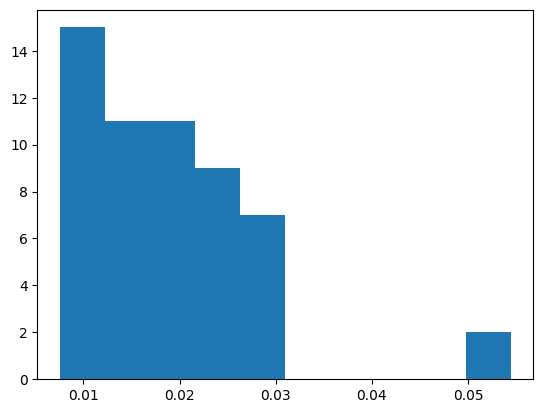

In [107]:
print(out)
print(check_sum_m_2_2) # viene 1!!!
hist_M = np.array([])
for i in range(len(M_out[0])):
    for j in range(i, len(M_out[0])):
        hist_M = np.append(hist_M, M_out[i,j])
plt.hist(hist_M)